# Fitting for an extended source polarization with `LeakageLib`

This jupyter notebook fits for the polarization of an extended source, with a photon and particle background. Here, the source is a 60 arcsecond-radius uniform disk, though because of the IXPE PSF, it appears wider in the IXPE data.

The source is assumed to have constant polarization, though we provide guidance on variable polarization sources at the end. Spatial, particle, and spectral weights are used.

In [10]:
import numpy as np
import leakagelib

The first step is to load the mock Moments data. We'll center it on pixel (300, 300), and cut to 280 arcseconds around that point. See the point source fit example for a description of these functions.

In [11]:
# Load the extended source data
datas = leakagelib.IXPEData.load_all_detectors_with_path("data", "extended")

for data in datas:
    data.explicit_center(300,300)
    data.retain(data.evt_energies > 2)
    data.retain(data.evt_energies < 8)

>>> Using cached xVignetting object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...


Now we have to create a custom `Source` object for our extended source: a 60"-radius disk. The source object should not be blurred by the PSF; i.e. it should depict the source as seen by Chandra, not IXPE

In [12]:
pixel_size = 2.9729 # This is the size of the sky PSF pixels; use it for best results
source_pixel_edges = np.arange(0, 280+pixel_size, pixel_size)
source_pixel_edges = np.concatenate([-np.flip(source_pixel_edges)[:-1], source_pixel_edges])
# source_pixel_edges now ranges from -280 to 280, centered on zero, and spaced by `pixel_size`
source_pixel_centers = (source_pixel_edges[1:] + source_pixel_edges[:-1]) / 2

xs, ys = np.meshgrid(source_pixel_centers, source_pixel_centers)
image = (np.sqrt(xs**2 + ys**2) < 60).astype(float)

source = leakagelib.Source(image, pixel_size)

<div class="alert alert-info">

**Alternatives to** `leakagelib.Source`

- `leakagelib.Source`. Load a source from an image.
- `leakagelib.Source.load_file`. Load a source from a FITS file.
- `leakagelib.Source.load_file`. Load a source from a FITS file.
- `leakagelib_cxo.cxo_source`. Load a CXO source TODO consider removing?
</div>

Now we give the source object to the fitter

In [13]:
settings = leakagelib.FitSettings(datas)
settings.add_source(source, "src-ext")
settings.fix_flux("src-ext", 1)
settings.set_initial_qu("src-ext", (0, 0))

The background and spectral weights are added in the same way as the previous fit, but this time we won't assume zero background polarization.

In [14]:
settings.add_background("bkg")
settings.set_initial_flux("bkg", 0.1)
settings.set_initial_qu("bkg", (0, 0))

We are assuming no particles for convenience. This is what you should do if you did not generate particle weights with `leakagelib_bkg`.

Now we add the spectral weights and ROI.

In [15]:
settings.set_spectrum("bkg", lambda e: e**-2.5)
settings.set_spectrum("src-ext", lambda e: e**-1.5)

settings.apply_circular_roi(280)

>>> Using cached xEffectiveArea object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...
>>> Using cached xVignetting object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...
>>> Using cached xEffectiveArea object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...
>>> Using cached xVignetting object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...
6420 events were cut for being outside the region of interest.


Let's view what the sources look like:

Let's view what the sources look like:

Data set extended DU 1 had no exposure map loaded. Please load an exposure map if you are fitting to events in the vignetted portion.


src-ext ['src-ext', 'bkg']
0 3
bkg ['src-ext', 'bkg']
1 3


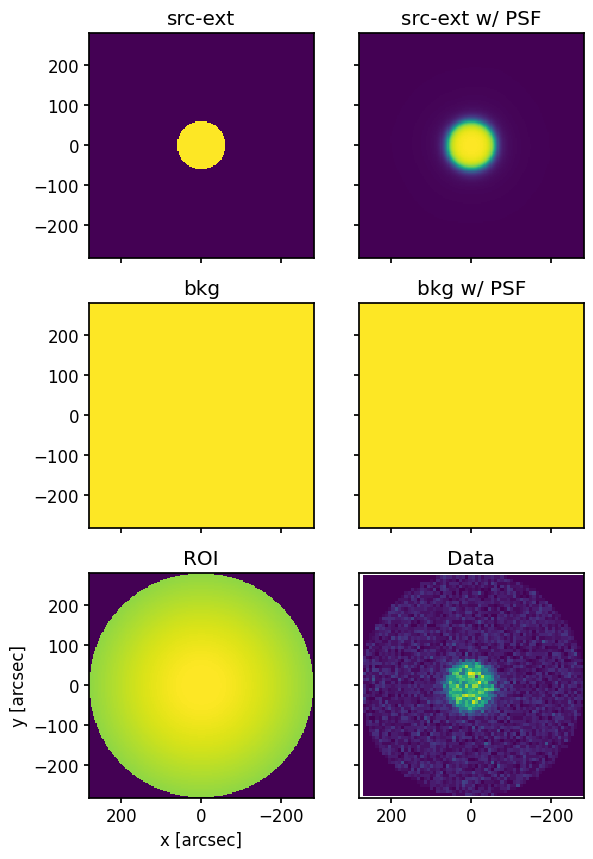

In [16]:
fitter = leakagelib.Fitter(settings)
fitter.display_sources(data_pixel_size=8);

It appears that the blurred source does indeed match the data well. We can also view what the fitter thinks the data should look like, based on the starting parameters

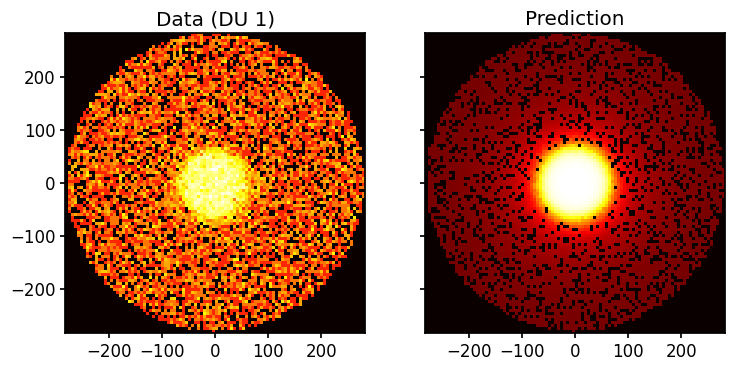

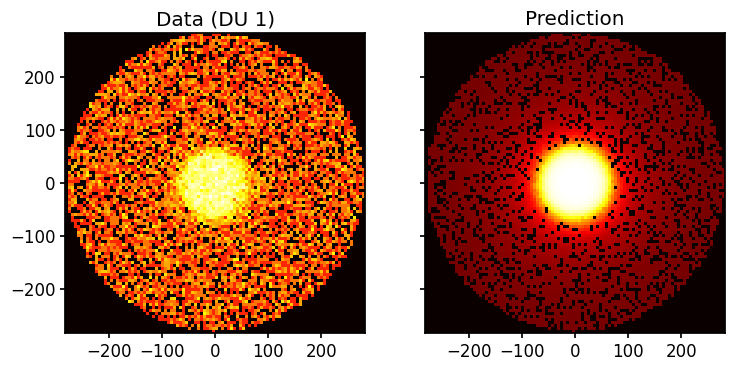

In [17]:
fitter.plot()

Finally, we perform the fit

In [18]:
result = fitter.fit()
result

FitResult:
	q (src-ext) = 0.4345 +/- 0.0764
	u (src-ext) = 0.0097 +/- 0.0764
	q (bkg) = -0.0175 +/- 0.0458
	u (bkg) = -0.0358 +/- 0.0463
	f (bkg) = 2.2394 +/- 0.0473

Polarization:
	PD (src-ext): 0.4346 +/- 0.0764
	PA (src-ext): 0.6394 deg +/- 5.0346
	PD (bkg): 0.0399 +/- 0.0462
	PA (bkg): -58.0476 deg +/- 32.9990
Likelihood 10951.238272268582, dof 15671
Optimization terminated successfully.

The true source polarization was q=0.5, u=0, which the fit agrees with.